In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', None)

## Load Data

In [ ]:
# Load data
df_pan = pd.read_csv("../datasets/final_data/pan_final.csv")
df_sandal = pd.read_csv("../datasets/final_data/sandal_final.csv")
df_sunscreen = pd.read_csv("../datasets/final_data/sunscreen_final.csv")
df_wallet = pd.read_csv("../datasets/final_data/wallet_final.csv")

## Config

In [129]:
import numpy as np

CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "val_size": 0.2,
    "cv_folds": 5,

    "stage2_trials": 100,

    "target_cols": ["z_sold", "z_rating_credibility"],

    "metrics": ["rmse", "mae", "r2"]
}

## Data Split

In [130]:
from sklearn.model_selection import train_test_split

def split_data(df, config):
    train_val, test = train_test_split(
        df,
        test_size=config["test_size"],
        random_state=config["random_seed"]
    )

    train, val = train_test_split(
        train_val,
        test_size=config["val_size"],
        random_state=config["random_seed"]
    )

    return train, val, test

## Feature Type Detection

In [131]:
def detect_feature_types(df):
    numeric = []
    categorical = []
    binary = []

    for col in df.columns:

        # skip ID-like columns where it has many unique values as rows
        if df[col].dtype == "object" and df[col].nunique() > 0.9 * len(df):
            continue
        
        # detect binary features (usually contains 0 or 1)
        if df[col].nunique() == 2: 
            binary.append(col)

        # convert to numeric if possible
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric.append(col)

        else:
            categorical.append(col)

    return numeric, categorical, binary

def select_features(df):
    cols = df.columns.tolist()

    drop_cols = {
        "target",
        "title",
        "sold",
        "reviews",
        "gmv_cal",
        "rating",
        "rating_credibility",
        "z_sold",
        "z_rating_credibility",
        "id",
        "seller_name"
    }

    drop_log_related = {
        "log_sold",
        "log_reviews",
        "log_gmv_cal"
    }

    selected = []

    for c in cols:
        if c in drop_cols or c in drop_log_related:
            continue

        selected.append(c)

    return selected

## Feature Split (Between Log and Non-Log)

In [132]:
def split_features_by_model(df, num_cols):

    log_cols = [c for c in num_cols if c.startswith("log_")]

    raw_cols = []
    for c in log_cols:
        raw = c.replace("log_", "")
        if raw in df.columns:
            raw_cols.append(raw)

    # numeric that are not log or raw pairs
    other_numeric = [
        c for c in num_cols
        if not c.startswith("log_") and c not in raw_cols
    ]

    return log_cols, raw_cols, other_numeric

## Target Engine (PCA + Bootstrap)

In [133]:
from sklearn.decomposition import PCA

def bootstrap_pca_weights(train, cols, n_boot=200):
    weights = []

    X = train[cols].values

    for _ in range(n_boot):
        # sample row of X
        idx = np.random.choice(len(X), len(X), replace=True)
        sample = X[idx]

        # fit PCA on sample
        pca = PCA(n_components=1)
        pca.fit(sample)

        w = pca.components_[0]

        # Align sign
        if w[0] < 0:
            w = -w

        weights.append(w)

    weights = np.array(weights)

    mean_w = weights.mean(axis=0)
    std_w = weights.std(axis=0)

    return mean_w, std_w


def create_target(df, weights, cols):
    return df[cols].values @ weights

## Preprocessing Pipelines

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate the columns for linear and tree models
# Convert categorical features to one-hot encoding for model that can't process categorical features directly
def build_linear_pipeline(df, num_cols, cat_cols):

    log_cols, _, other_numeric = split_features_by_model(df, num_cols)

    linear_num_cols = log_cols + other_numeric

    print("\n[DEBUG] Linear features:")
    print(linear_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, linear_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])


def build_tree_pipeline(df, num_cols, cat_cols):

    log_cols, raw_cols, other_numeric = split_features_by_model(df, num_cols)

    tree_num_cols = raw_cols + other_numeric

    print("\n[DEBUG] Tree features:")
    print(tree_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, tree_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

## List of Models

In [135]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor


def get_models():
    return {
        # Baselines (to see if there is any linear relationship, and to check if more complex models are needed)
        "linear_regression": LinearRegression(),
        "ridge": Ridge(),
        "lasso": Lasso(),
        "elastic_net": ElasticNet(),

        # Tree Models
        "random_forest": RandomForestRegressor(),
        "extra_trees": ExtraTreesRegressor(),

        # Boosting 
        "xgboost": xgb.XGBRegressor(tree_method="hist"),
        "lightgbm": lgb.LGBMRegressor(verbosity=-1),
        "catboost": CatBoostRegressor(verbose=0),

        # Others
        "svr": SVR(),
        "knn": KNeighborsRegressor()
    }

## Evaluation Metrics

In [136]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

## Stage 1 - Fast Screening

In [137]:
from sklearn.model_selection import cross_validate

def stage1_search(models, X, y, preprocessors, config):

    results = []

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    for name, model in models.items():

        pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring=scoring,
            return_train_score=False
        )

        results.append({
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_sd": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean()
        })

    # sort
    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean")

    # select top models
    top_models = results_df.head(3).to_dict("records")

    return top_models, results_df

## Stage 2 - Optuna Tuning

In [138]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def tune_model(model_name, X, y, preprocessor, config):

    def objective(trial):

        # Linear Models
        if model_name == "linear_regression":
            model = LinearRegression()

        elif model_name == "ridge":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)
            }
            model = Ridge(**params)

        elif model_name == "lasso":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)
            }
            model = Lasso(**params)

        elif model_name == "elastic_net":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
                "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
            }
            model = ElasticNet(**params)

        # Tree Models
        elif model_name == "random_forest":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
            }
            model = RandomForestRegressor(**params)

        elif model_name == "extra_trees":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
            }
            model = ExtraTreesRegressor(**params)

        # Boosting Models
        elif model_name == "xgboost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)
            }
            model = xgb.XGBRegressor(tree_method="hist", **params)

        elif model_name == "lightgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
                "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 50)
            }
            model = lgb.LGBMRegressor(**params, verbosity=-1)

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 800),
                "depth": trial.suggest_int("depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "border_count": trial.suggest_int("border_count", 32, 255)
            }
            model = CatBoostRegressor(**params, verbose=0)

        # SVR
        elif model_name == "svr":
            params = {
                "C": trial.suggest_float("C", 0.1, 100, log=True),
                "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
            }
            model = SVR(**params)

        # KNN
        elif model_name == "knn":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2)
            }
            model = KNeighborsRegressor(**params)

        else:
            raise ValueError(f"No tuning defined for {model_name}")

        # PIPELINE
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ])

        score = cross_val_score(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring="neg_root_mean_squared_error"
        ).mean()

        return -score

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=config["stage2_trials"])

    return study.best_params

## Final Training

In [139]:
def train_final(model, preprocessor, X_train, y_train):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

## Weighted Ensemble Model

In [140]:
def weighted_ensemble(preds, rmses):
    # Set the weight based on RMSE values (lower RMSE gets higher weight)
    weights = 1 / np.array(rmses)
    weights /= weights.sum()

    final_pred = sum(w * p for w, p in zip(weights, preds))

    return final_pred, weights

# Get the weighted average for ensemble model feature importance
def get_weighted_ensemble_importance(
    trained_models,
    weights,
    X_train,
    top_n=10
):
    import pandas as pd
    import numpy as np

    all_importances = []

    for model, w in zip(trained_models, weights):

        m = model.named_steps["model"]
        prep = model.named_steps["prep"]

        # Get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

        # Get importance
        if hasattr(m, "feature_importances_"):
            imp = m.feature_importances_

        elif hasattr(m, "coef_"):
            imp = np.abs(m.coef_)

        else:
            continue

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": imp * w 
        })

        all_importances.append(df)

    # Combine all
    final_df = pd.concat(all_importances)

    # Aggregate
    final_df = final_df.groupby("feature")["importance"].sum().reset_index()

    final_df = final_df.sort_values("importance", ascending=False).head(top_n)

    return final_df

def plot_ensemble_importance(importance_df):

    import matplotlib.pyplot as plt
    
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.gca().invert_yaxis()

    plt.title("Weighted Ensemble Feature Importance")
    plt.xlabel("Weighted Importance")

    plt.tight_layout()
    plt.show()


## Plot Feature Importance

In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(model, prep, X_train, top_n=10, title="Feature Importance"):

    # Get transformed feature names
    try:
        feature_names = prep.get_feature_names_out()
    except:
        feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

    # Get importance
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

    else:
        print("[WARN] Model does not support feature importance")
        return

    # Create DataFrame
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

    # Plot
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

## SHAP Analysis

In [142]:
def shap_thresholds_with_interpretation(
    X,
    shap_values,
    feature_names,
    top_n=10,
    quantile=0.2
):

    shap_abs = np.abs(shap_values).mean(axis=0)

    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": shap_abs
    }).sort_values("importance", ascending=False)

    top_features = importance.head(top_n)["feature"].values

    results = []

    for f in top_features:

        # Categorical
        if "cat__" in f:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Category impacts prediction when present",
                "insight": "Interpret category presence vs absence"
            })
            continue

        try:
            idx = feature_names.tolist().index(f)

            x = X[:, idx]
            y = shap_values[:, idx]

            df = pd.DataFrame({"x": x, "shap": y})

            # Positive Impact Region
            pos_threshold = df["shap"].quantile(1 - quantile)
            pos_region = df[df["shap"] >= pos_threshold]


            # NEGATIVE IMPACT REGION
            neg_threshold = df["shap"].quantile(quantile)
            neg_region = df[df["shap"] <= neg_threshold]

            # Extract ranges
            pos_min, pos_max = pos_region["x"].min(), pos_region["x"].max()
            neg_min, neg_max = neg_region["x"].min(), neg_region["x"].max()

            # Convert log to real values
            if "log_" in f:
                pos_min_real = np.exp(pos_min) - 1
                pos_max_real = np.exp(pos_max) - 1
                neg_min_real = np.exp(neg_min) - 1
                neg_max_real = np.exp(neg_max) - 1
                name = f.replace("num__log_", "")
            else:
                pos_min_real, pos_max_real = pos_min, pos_max
                neg_min_real, neg_max_real = neg_min, neg_max
                name = f.replace("num__", "")

            # Determine direction
            pos_mean = pos_region["x"].mean()
            neg_mean = neg_region["x"].mean()

            # High positive = higher is better, High negative = lower is better
            if pos_mean > neg_mean:
                direction = "higher"
                recommendation = f"Increase {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"
            else:
                direction = "lower"
                recommendation = f"Reduce {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"

            results.append({
                "feature": f,
                "positive_range": f"{pos_min_real:.2f} – {pos_max_real:.2f}",
                "negative_range": f"{neg_min_real:.2f} – {neg_max_real:.2f}",
                "recommendation": recommendation,
                "interpretation": interpretation,
                "insight": f"{direction} values drive better performance"
            })

        except Exception as e:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Failed",
                "interpretation": "Error",
                "insight": str(e)
            })

    return pd.DataFrame(results)

## SHAP Input Validation

In [143]:
def validate_shap_input(X, feature_names):
    import pandas as pd
    import numpy as np

    df = pd.DataFrame(X, columns=feature_names)

    # Exclude non-numeric columns
    bad_cols = []
    for col in df.columns:
        if df[col].dtype == "object":
            bad_cols.append(col)

    if bad_cols:
        print("\n[WARNING] Non-numeric columns detected for SHAP:")
        print(bad_cols)

    # keep only numeric
    numeric_df = df.select_dtypes(include=[np.number])

    dropped = set(df.columns) - set(numeric_df.columns)
    if dropped:
        print("\n[INFO] Dropping incompatible columns:")
        print(list(dropped))

    return numeric_df.values, numeric_df.columns

## Feature Recommendations

In [144]:
def generate_feature_recommendations(
    model,
    X,
    top_features,
    n_bins=10
):
    import pandas as pd
    import numpy as np

    # Split feature values into bins
    def create_bins(series, n_bins=10):
        try:
            return pd.qcut(series, n_bins, duplicates="drop")
        except:
            return pd.cut(series, n_bins)
    
    # Summarize performance per bin for a given feature to see which ranges give higher predicted success
    def summarize_bins(feature, X, preds):
        df = pd.DataFrame({
            "feature": X[feature],
            "pred": preds
        })

        if pd.api.types.is_numeric_dtype(df["feature"]):
            df["bin"] = create_bins(df["feature"])
            summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

            # extract min/max
            summary["feature_min"] = summary["feature_bin"].apply(lambda x: x.left if hasattr(x, "left") else None)
            summary["feature_max"] = summary["feature_bin"].apply(lambda x: x.right if hasattr(x, "right") else None)

        else:
            summary = df.groupby("feature")["pred"].mean().reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

        # Rank bins from the best performing range
        return summary.sort_values("predicted_mean", ascending=False)

    def derive_recommendation(feature, X, bin_summary):
        series = X[feature]
        is_numeric = pd.api.types.is_numeric_dtype(series)

        if bin_summary.empty:
            return None

        best_row = bin_summary.iloc[0]

        # For numeric features, recommend the range of the best performing bin
        if is_numeric:
            current_typical = series.median()

            if "feature_min" in bin_summary.columns:
                recommended_range = f"{best_row['feature_min']:.4g} to {best_row['feature_max']:.4g}"
            else:
                recommended_range = None

            return {
                "feature": feature,
                "current_typical_value": round(float(current_typical), 4),
                "recommended_target_or_range": recommended_range,
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Optimal range based on model prediction"
            }
        
        # For categorical features, get the most common category
        else:
            current_mode = series.mode(dropna=True)
            current_mode = current_mode.iloc[0] if len(current_mode) > 0 else None

            return {
                "feature": feature,
                "current_typical_value": current_mode,
                "recommended_target_or_range": str(best_row["feature_bin"]),
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Best performing category"
            }

    # Run pipeline
    preds = model.predict(X)

    rows = []

    for f in top_features:
        if f not in X.columns:
            continue

        summary = summarize_bins(f, X, preds)
        row = derive_recommendation(f, X, summary)

        if row:
            rows.append(row)

    return pd.DataFrame(rows)

### Template to track progress

In [145]:
import time
import numpy as np

def log(msg):
    print(f"[INFO] {msg}")

def log_section(title):
    print("\n" + "="*50)
    print(f"[STAGE] {title}")
    print("="*50)

# Main Pipeline

In [146]:
def run_pipeline(df):

    start_time = time.time()

    # -------------------------
    # 1. Split
    # -------------------------
    log_section("1. DATA SPLIT")

    train, val, test = split_data(df, CONFIG)

    log(f"Train shape: {train.shape}")
    log(f"Validation shape: {val.shape}")
    log(f"Test shape: {test.shape}")

    # -------------------------
    # 2. Target (PCA + Bootstrap)
    # -------------------------
    log_section("2. TARGET ENGINE (PCA + BOOTSTRAP)")

    weights, std = bootstrap_pca_weights(train, CONFIG["target_cols"])

    log(f"PCA Weights: {weights}")
    log(f"Weight STD: {std}")

    train["target"] = create_target(train, weights, CONFIG["target_cols"])
    val["target"] = create_target(val, weights, CONFIG["target_cols"])
    test["target"] = create_target(test, weights, CONFIG["target_cols"])

    # -------------------------
    # Normalize PCA weights (sum to 100%)
    # -------------------------
    log_section("PCA NORMALIZED WEIGHTS (%)")

    # absolute weights to avoid sign issue
    w_abs = np.abs(weights)

    # normalize to sum = 1
    w_pct = w_abs / np.sum(w_abs)

    # convert std to percentage space
    std_pct = std / np.sum(w_abs)

    # print
    for col, w, s in zip(CONFIG["target_cols"], w_pct, std_pct):
        log(f"{col}: {w*100:.2f}% ± {s*100:.2f}%")

    pca_weight_summary = pd.DataFrame({
        "component": CONFIG["target_cols"],
        "weight_raw": weights,
        "weight_std": std,
        "weight_pct": w_pct * 100,
        "std_pct": std_pct * 100
    })

    print("\nPCA Weight Summary Table:")
    print(pca_weight_summary.to_string(index=False))

    # -------------------------
    # 3. Feature Selection
    # -------------------------
    log_section("3. FEATURE SELECTION")

    feature_cols = select_features(train)
    log(f"Selected features: {len(feature_cols)}")

    X_train = train[feature_cols]
    y_train = train["target"]

    X_val = val[feature_cols]
    y_val = val["target"]

    X_test = test[feature_cols]
    y_test = test["target"]

    # -------------------------
    # 4. Feature types
    # -------------------------
    log_section("4. FEATURE TYPE DETECTION")

    num_cols, cat_cols, bin_cols = detect_feature_types(X_train)

    log(f"# Numeric: {len(num_cols)}")
    log(f"# Categorical: {len(cat_cols)}")
    log(f"# Binary: {len(bin_cols)}")

    # -------------------------
    # 5. Pipelines
    # -------------------------
    log_section("5. BUILD PIPELINES")

    linear_prep = build_linear_pipeline(X_train, num_cols, cat_cols)
    tree_prep = build_tree_pipeline(X_train, num_cols, cat_cols)

    # -------------------------
    # 6. Models
    # -------------------------
    log_section("6. MODEL REGISTRY")

    models = get_models()

    # Model family mapping
    linear_models = {
        "linear_regression",
        "ridge",
        "lasso",
        "elastic_net"
    }

    tree_models = {
        "random_forest",
        "extra_trees",
        "xgboost",
        "lightgbm",
        "catboost"
    }

    other_models = {
        "svr",
        "knn"
    }

    # Build preprocessors dynamically
    preprocessors = {}

    for name in models.keys():
        if name in linear_models:
            preprocessors[name] = linear_prep

        elif name in tree_models:
            preprocessors[name] = tree_prep
        
        elif name in other_models:
            preprocessors[name] = linear_prep

        else:
            raise ValueError(f"Unknown model type: {name}")

    log(f"Preprocessors assigned for {len(preprocessors)} models")

    # -------------------------
    # 7. Stage 1 Search (Quick CV to find promising models)
    # -------------------------
    log_section("7. STAGE 1: FAST SCREENING")

    top_models, all_results = stage1_search(
        models, X_train, y_train, preprocessors, CONFIG
    )

    log_section("STAGE 1 MODEL PERFORMANCE TABLE")

    stage1_df = all_results.copy()

    print(stage1_df.to_string(index=False))

    # plot
    plt.figure()
    plt.barh(stage1_df["model"], stage1_df["cv_rmse_mean"])
    plt.xlabel("RMSE")
    plt.title("Stage 1 Model Performance (Lower is Better)")
    plt.gca().invert_yaxis()
    plt.show()

    log(f"Top models: {[m['model'] for m in top_models]}")
    
    
    # -------------------------
    # 8. Stage 2 Hyperparameter Tuning
    # -------------------------

    log_section("8. STAGE 2: HYPERPARAMETER TUNING")

    tuned_models = {}

    for m in top_models:
        name = m["model"]

        log(f"Tuning model: {name}")

        best_params = tune_model(
            name,
            X_train,
            y_train,
            preprocessors[name],
            CONFIG
        )

        log(f"Best params for {name}: {best_params}")

        # rebuild model with best params
        if name == "xgboost":
            model = xgb.XGBRegressor(**best_params)

        elif name == "lightgbm":
            model = lgb.LGBMRegressor(**best_params)

        elif name == "catboost":
            model = CatBoostRegressor(**best_params)

        elif name == "random_forest":
            model = RandomForestRegressor(**best_params)

        elif name == "ridge":
            model = Ridge(**best_params)

        elif name == "elastic_net":
            model = ElasticNet(**best_params)

        else:
            continue

        pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        tuned_models[name] = pipe
    

    tuning_summary = []
    
    tuning_summary.append({
        "model": name,
        "n_trials": CONFIG["stage2_trials"],
        "best_params": best_params
    })

    tuning_summary_df = pd.DataFrame(tuning_summary)
    print("\nTuning Summary:")
    print(tuning_summary_df.to_string(index=False))

    # -------------------------
    # 9. Train finalists + table
    # -------------------------
    log_section("9. FINALIZE MODELS")

    trained_models = []
    val_preds = []
    rmses = []
    results_table = []

    for m in top_models:
        name = m["model"]

        log(f"Training: {name}")

        pipe = train_final(
            models[name],
            preprocessors[name],
            X_train, y_train
        )

        pred = pipe.predict(X_val)
        metrics = evaluate(y_val, pred)

        trained_models.append(pipe)
        val_preds.append(pred)
        rmses.append(metrics["rmse"])

        results_table.append({
            "model": name,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"]
        })

    # -------------------------
    # STAGE 1 vs STAGE 2 COMPARISON (FIXED)
    # -------------------------
    log_section("MODEL IMPROVEMENT (STAGE 1 vs STAGE 2)")

    # Convert results_table to DataFrame for easy lookup
    results_df_stage2 = pd.DataFrame(results_table)

    comparison_rows = []

    for m in top_models:

        name = m["model"]

        # Stage 1 (CV)
        stage1_rmse = m["cv_rmse_mean"]
        stage1_mae = m["cv_mae_mean"]
        stage1_r2 = m["cv_r2_mean"]

        # Stage 2 (Validation) — match by model name
        row_stage2 = results_df_stage2[results_df_stage2["model"] == name]

        if row_stage2.empty:
            continue 

        row_stage2 = row_stage2.iloc[0]

        stage2_rmse = row_stage2["rmse"]
        stage2_mae = row_stage2["mae"]
        stage2_r2 = row_stage2["r2"]

        comparison_rows.append({
            "model": name,

            # Stage 1
            "stage1_rmse": stage1_rmse,
            "stage1_mae": stage1_mae,
            "stage1_r2": stage1_r2,

            # Stage 2
            "stage2_rmse": stage2_rmse,
            "stage2_mae": stage2_mae,
            "stage2_r2": stage2_r2,

            # Improvement
            "rmse_improvement": stage1_rmse - stage2_rmse,
            "mae_improvement": stage1_mae - stage2_mae,
            "r2_improvement": stage2_r2 - stage1_r2
        })

    comparison_df = pd.DataFrame(comparison_rows)

    print(comparison_df.to_string(index=False))

    # -------------------------
    # TOP MODELS FEATURE IMPORTANCE (NEW)
    # -------------------------
    log_section("TOP MODELS FEATURE IMPORTANCE")

    top3_idx = np.argsort(rmses)[:3]

    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(top3_idx):
        model = trained_models[idx]
        name = top_models[idx]["model"]

        plt.figure(figsize=(12,5))

        plot_feature_importance(
            model.named_steps["model"],
            model.named_steps["prep"],
            X_train,
            top_n=10,
            title=f"{name} (R2={results_table[idx]['r2']:.3f})"
        )

    plt.tight_layout()
    plt.show()

    # -------------------------
    # 10. Ensemble
    # -------------------------
    log_section("10. ENSEMBLE")

    ensemble_pred, weights = weighted_ensemble(val_preds, rmses)
    ensemble_metrics = evaluate(y_val, ensemble_pred)

    results_table.append({
        "model": "ensemble",
        "rmse": ensemble_metrics["rmse"],
        "mae": ensemble_metrics["mae"],
        "r2": ensemble_metrics["r2"]
    })

    # -------------------------
    # ENSEMBLE FEATURE IMPORTANCE
    # -------------------------
    log_section("ENSEMBLE FEATURE IMPORTANCE")

    ensemble_importance_df = get_weighted_ensemble_importance(
        trained_models=trained_models,
        weights=weights,
        X_train=X_train,
        top_n=10
    )

    print(ensemble_importance_df.to_string(index=False))

    plot_ensemble_importance(ensemble_importance_df)

    # -------------------------
    # 11. PRINT TABLE
    # -------------------------
    log_section("11. MODEL PERFORMANCE TABLE")

    results_df = pd.DataFrame(results_table).sort_values("rmse")

    print(results_df.to_string(index=False))

    best_model_idx = np.argmin(rmses)
    best_model = trained_models[best_model_idx]

    log(f"Best model: {top_models[best_model_idx]['model']}")

    # -------------------------
    # 12. SHAP ANALYSIS
    # -------------------------
    log_section("12. SHAP ANALYSIS")

    try:
        X_sample = X_val.sample(min(1000, len(X_val)), random_state=42)

        # Extract pipeline parts
        prep = best_model.named_steps["prep"]
        model = best_model.named_steps["model"]

        X_transformed = prep.transform(X_sample)

        # convert to dense if sparse
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        # get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        X_transformed, feature_names = validate_shap_input(
            X_transformed,
            feature_names
        )

        # Try to get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer (tree-safe)
        explainer = shap.Explainer(model, X_transformed)

        shap_values = explainer(X_transformed)

        log("SHAP summary plot generating...")

        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

        # -------------------------
        # SHAP threshold analysis
        # -------------------------

        log_section("SHAP THRESHOLD ANALYSIS")

        threshold_df = shap_thresholds_with_interpretation(
            X_transformed,
            shap_values.values,
            feature_names,
            top_n=10
        )

        print(threshold_df.to_string(index=False))

        top_feature = threshold_df.iloc[0]["feature"]

        idx = list(feature_names).index(top_feature)

        x = X_transformed[:, idx]
        y = shap_values.values[:, idx]

    except Exception as e:
        log(f"SHAP failed: {e}")


    # -------------------------
    # 13. FEATURE RECOMMENDATION TABLE
    # -------------------------
    log_section("13. FEATURE RECOMMENDATION")

    # get top features from importance
    top_features = [f.split("__")[-1] for f in feature_names[:10]]

    # IMPORTANT: use ORIGINAL X_val (not transformed)
    recommendation_df = generate_feature_recommendations(
        model=best_model,
        X=X_val,
        top_features=top_features,
        n_bins=10
    )

    print(recommendation_df.to_string(index=False))

    # -------------------------
    # 14. FINAL SUMMARY
    # -------------------------
    log_section("14. FINAL SUMMARY")

    log(f"Total runtime: {time.time() - start_time:.2f}s")

    return {
        "results_table": results_df
    }

## SUNSCREEN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2156, 44)
[INFO] Validation shape: (540, 44)
[INFO] Test shape: (675, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.58099303 0.77033155]
[INFO] Weight STD: [0.1977434  0.17301432]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 42.99% ± 14.63%
[INFO] z_rating_credibility: 57.01% ± 12.80%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.580993    0.197743   42.994336 14.633302
z_rating_credibility    0.770332    0.173014   57.005664 12.803313

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 31

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 22
[INFO] # Categorical: 6
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat

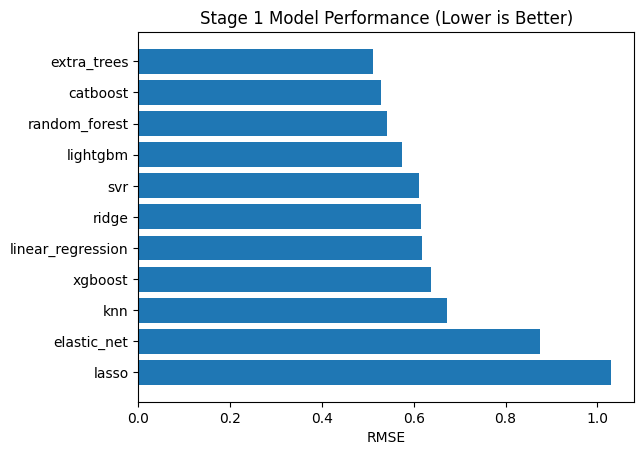

[I 2026-04-14 00:44:21,471] A new study created in memory with name: no-name-7ac1a763-9971-406b-ac1c-c5ba927b0f45


[INFO] Top models: ['extra_trees', 'catboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: extra_trees


[I 2026-04-14 00:44:49,202] Trial 0 finished with value: 0.5197056534249801 and parameters: {'n_estimators': 299, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5197056534249801.
[I 2026-04-14 00:44:56,436] Trial 1 finished with value: 0.775130305978833 and parameters: {'n_estimators': 339, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5197056534249801.
[I 2026-04-14 00:45:11,357] Trial 2 finished with value: 0.5544173313742723 and parameters: {'n_estimators': 251, 'max_depth': 29, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5197056534249801.
[I 2026-04-14 00:45:22,256] Trial 3 finished with value: 0.524732487374188 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5197056534249801.
[I 2026-04-14 00:45:34,597] Trial 4 finished with value: 0.5229528057214323 and parameters: {

[INFO] Best params for extra_trees: {'n_estimators': 324, 'max_depth': 27, 'min_samples_split': 3, 'min_samples_leaf': 1}
[INFO] Tuning model: catboost


[I 2026-04-14 01:01:44,345] Trial 0 finished with value: 0.5542162216155734 and parameters: {'iterations': 358, 'depth': 9, 'learning_rate': 0.1825724231026761, 'l2_leaf_reg': 7.8195729296096985, 'border_count': 121}. Best is trial 0 with value: 0.5542162216155734.
[I 2026-04-14 01:01:55,086] Trial 1 finished with value: 0.5472292219132486 and parameters: {'iterations': 761, 'depth': 8, 'learning_rate': 0.13325037202068948, 'l2_leaf_reg': 4.667800011618601, 'border_count': 118}. Best is trial 1 with value: 0.5472292219132486.
[I 2026-04-14 01:02:00,498] Trial 2 finished with value: 0.5937314066607644 and parameters: {'iterations': 339, 'depth': 8, 'learning_rate': 0.013743084796405602, 'l2_leaf_reg': 8.588594749385248, 'border_count': 150}. Best is trial 1 with value: 0.5472292219132486.
[I 2026-04-14 01:02:09,557] Trial 3 finished with value: 0.5430291019170971 and parameters: {'iterations': 742, 'depth': 7, 'learning_rate': 0.011506798397241573, 'l2_leaf_reg': 3.991905624019742, 'bor

...

[I 2026-04-14 01:18:28,840] A new study created in memory with name: no-name-7e49117c-1bbd-458a-b74a-d0ce277c229c


677:	learn: 0.0968823	total: 1.76s	remaining: 154ms
678:	learn: 0.0968406	total: 1.77s	remaining: 151ms
679:	learn: 0.0966119	total: 1.77s	remaining: 148ms
680:	learn: 0.0961177	total: 1.77s	remaining: 146ms
681:	learn: 0.0960726	total: 1.77s	remaining: 143ms
682:	learn: 0.0958696	total: 1.78s	remaining: 141ms
683:	learn: 0.0956316	total: 1.78s	remaining: 138ms
684:	learn: 0.0954651	total: 1.78s	remaining: 135ms
685:	learn: 0.0954560	total: 1.79s	remaining: 133ms
686:	learn: 0.0952934	total: 1.79s	remaining: 130ms
687:	learn: 0.0950212	total: 1.79s	remaining: 128ms
688:	learn: 0.0949970	total: 1.79s	remaining: 125ms
689:	learn: 0.0949870	total: 1.8s	remaining: 122ms
690:	learn: 0.0949651	total: 1.8s	remaining: 120ms
691:	learn: 0.0946586	total: 1.8s	remaining: 117ms
692:	learn: 0.0943233	total: 1.81s	remaining: 115ms
693:	learn: 0.0940552	total: 1.81s	remaining: 112ms
694:	learn: 0.0937125	total: 1.81s	remaining: 109ms
695:	learn: 0.0936017	total: 1.81s	remaining: 107ms
696:	learn: 0.0

[I 2026-04-14 01:18:30,377] Trial 0 finished with value: 0.6747161104991257 and parameters: {'n_estimators': 161, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.6747161104991257.
[I 2026-04-14 01:18:32,860] Trial 1 finished with value: 0.6747808768055071 and parameters: {'n_estimators': 282, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.6747161104991257.
[I 2026-04-14 01:18:36,224] Trial 2 finished with value: 0.6440973480997843 and parameters: {'n_estimators': 327, 'max_depth': 27, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.6440973480997843.
[I 2026-04-14 01:18:39,854] Trial 3 finished with value: 0.6093754804970871 and parameters: {'n_estimators': 308, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.60937548049708

[INFO] Best params for random_forest: {'n_estimators': 352, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model  n_trials                                                                                                   best_params
random_forest       100 {'n_estimators': 352, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

[STAGE] 9. FINALIZE MODELS
[INFO] Training: extra_trees
[INFO] Training: catboost
[INFO] Training: random_forest

[STAGE] MODEL IMPROVEMENT (STAGE 1 vs STAGE 2)
        model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_improvement  r2_improvement
  extra_trees     0.510829    0.270775   0.750398     0.425001    0.269366   0.759048          0.085829         0.001410        0.008650
     catboost     0.529361    0.261526   0.734703     0.381704    0.248024   0.805642          0.147657         0.013502        0.0

<Figure size 1200x600 with 0 Axes>

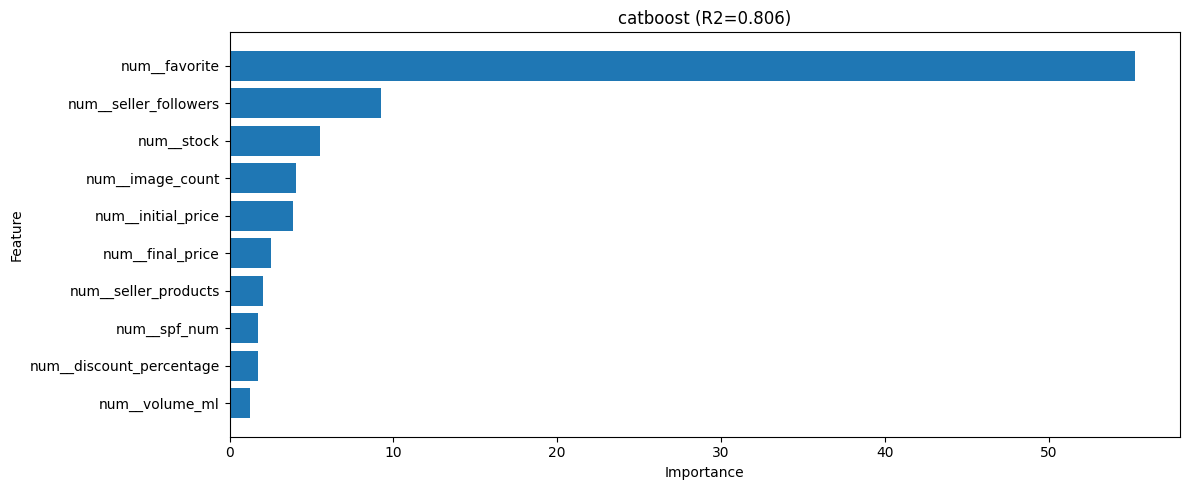

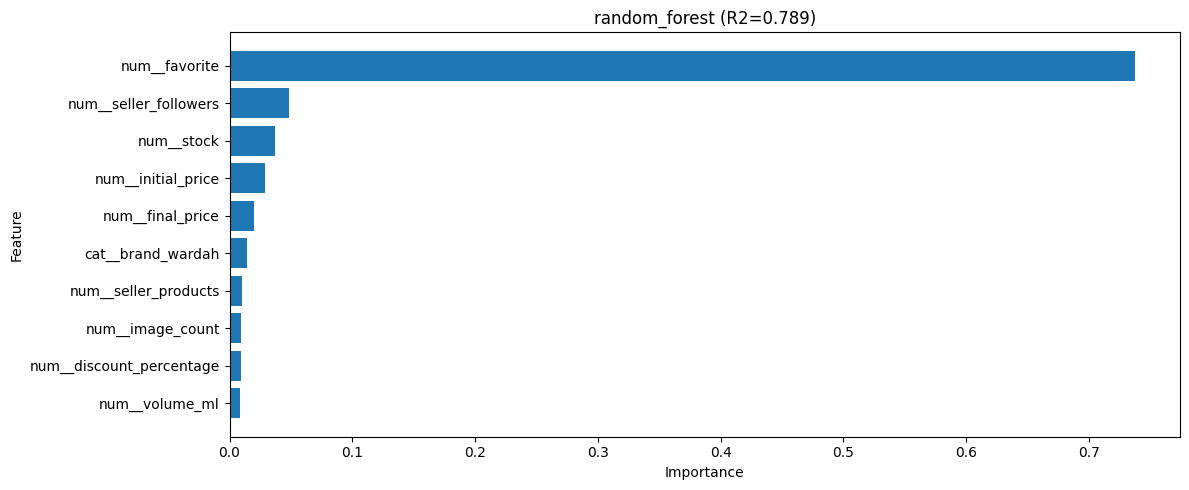

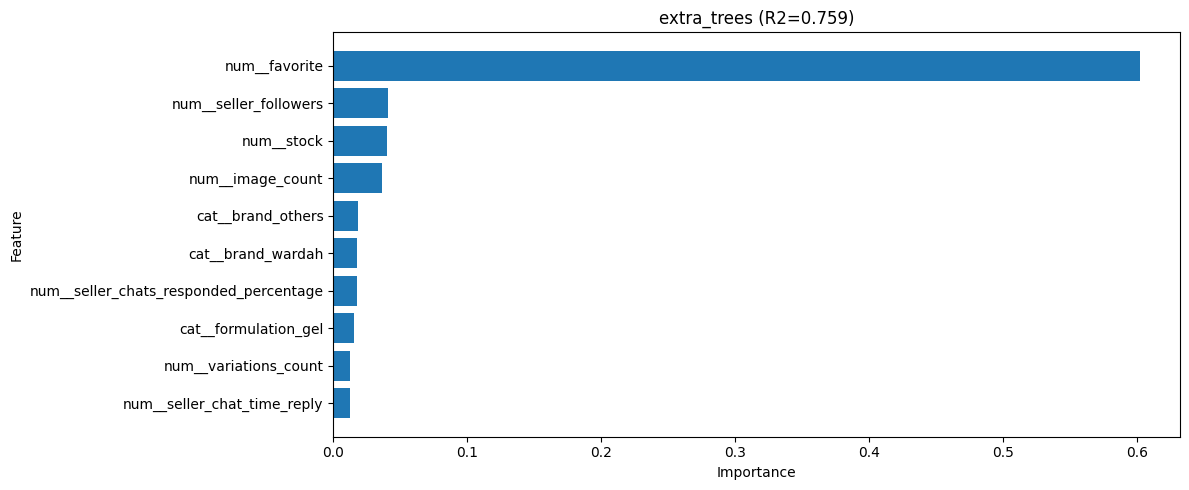

<Figure size 640x480 with 0 Axes>


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                 feature  importance
           num__favorite   19.776441
   num__seller_followers    3.274898
              num__stock    1.968232
        num__image_count    1.437308
      num__initial_price    1.364556
        num__final_price    0.889065
    num__seller_products    0.718264
num__discount_percentage    0.615933
            num__spf_num    0.615050
          num__volume_ml    0.449733


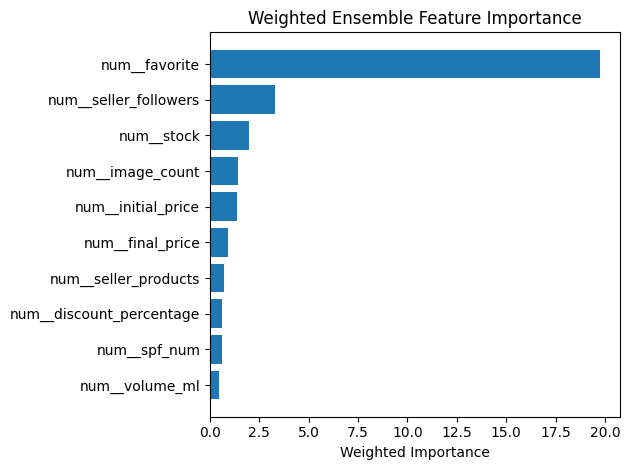


[STAGE] 11. MODEL PERFORMANCE TABLE
        model     rmse      mae       r2
     ensemble 0.381365 0.244756 0.805987
     catboost 0.381704 0.248024 0.805642
random_forest 0.397825 0.251078 0.788877
  extra_trees 0.425001 0.269366 0.759048
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 96%|=================== | 520/540 [00:15<00:00]       

[INFO] SHAP summary plot generating...


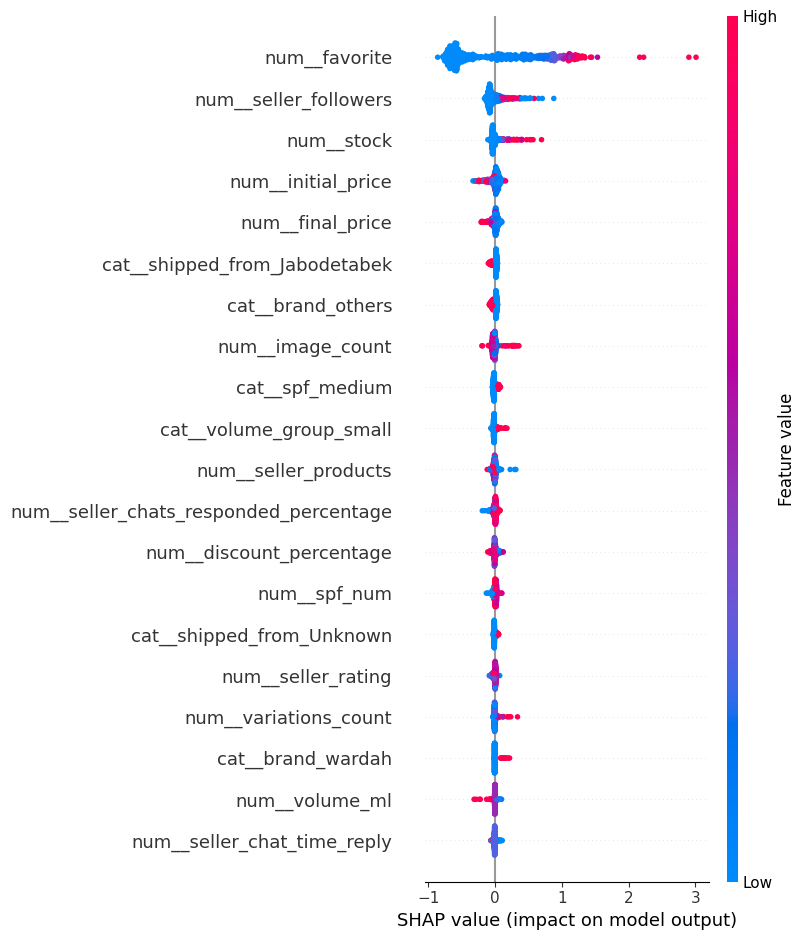


[STAGE] SHAP THRESHOLD ANALYSIS
                      feature       positive_range       negative_range                           recommendation                       interpretation                                insight
                num__favorite     61.00 – 27340.00          0.00 – 4.00                        Increase favorite          favorite ≈ 61.00 – 27340.00 higher values drive better performance
        num__seller_followers    2.00 – 8156548.00     22.00 – 19400.00                Increase seller_followers seller_followers ≈ 2.00 – 8156548.00 higher values drive better performance
                   num__stock  43.00 – 24995859.00        0.00 – 324.00                           Increase stock          stock ≈ 43.00 – 24995859.00 higher values drive better performance
           num__initial_price 15000.00 – 880000.00 2900.00 – 1300000.00                     Reduce initial_price initial_price ≈ 15000.00 – 880000.00  lower values drive better performance
             num__fina

C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

{'results_table':            model      rmse       mae        r2
 3       ensemble  0.381365  0.244756  0.805987
 1       catboost  0.381704  0.248024  0.805642
 2  random_forest  0.397825  0.251078  0.788877
 0    extra_trees  0.425001  0.269366  0.759048}

In [147]:
df_sunscreen = df_sunscreen.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_sunscreen)

## SANDAL MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (6400, 43)
[INFO] Validation shape: (1600, 43)
[INFO] Test shape: (2000, 43)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.71716865 0.69610614]
[INFO] Weight STD: [0.02314129 0.02387165]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 50.75% ± 1.64%
[INFO] z_rating_credibility: 49.25% ± 1.69%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.717169    0.023141   50.745167 1.637423
z_rating_credibility    0.696106    0.023872   49.254833 1.689102

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 30

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 18
[INFO] # Categorical: 9
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_seller_products', 'log_seller_followers', 'log_initial_price', 'log_stock', 'log_favorite', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_time_reply', 'vari

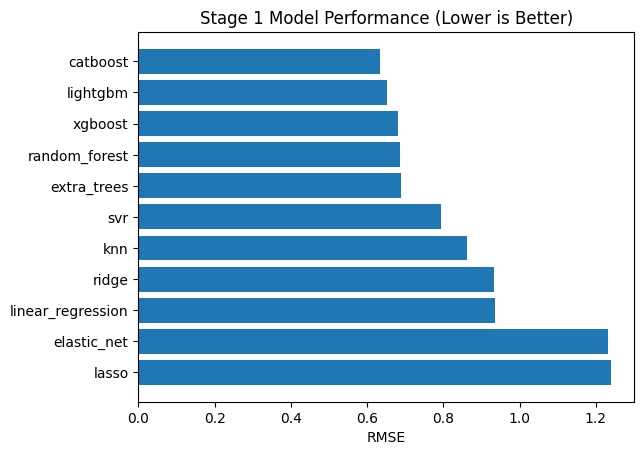

[I 2026-04-14 01:30:30,183] A new study created in memory with name: no-name-72db2116-66f5-4dc7-a729-44a19e415983


[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-14 01:30:33,254] Trial 0 finished with value: 0.6852783347172352 and parameters: {'iterations': 244, 'depth': 7, 'learning_rate': 0.05764792383814114, 'l2_leaf_reg': 5.04237185429137, 'border_count': 98}. Best is trial 0 with value: 0.6852783347172352.
[I 2026-04-14 01:30:35,083] Trial 1 finished with value: 0.692472598206486 and parameters: {'iterations': 256, 'depth': 4, 'learning_rate': 0.1271560970400031, 'l2_leaf_reg': 5.383900297102726, 'border_count': 88}. Best is trial 0 with value: 0.6852783347172352.
[I 2026-04-14 01:30:41,268] Trial 2 finished with value: 0.7196812372310044 and parameters: {'iterations': 205, 'depth': 9, 'learning_rate': 0.03368966130561373, 'l2_leaf_reg': 4.470765481170616, 'border_count': 131}. Best is trial 0 with value: 0.6852783347172352.
[I 2026-04-14 01:30:47,202] Trial 3 finished with value: 0.7139075556627166 and parameters: {'iterations': 502, 'depth': 6, 'learning_rate': 0.01712628496867458, 'l2_leaf_reg': 1.309859895893827, 'border_cou

[INFO] Best params for catboost: {'iterations': 789, 'depth': 7, 'learning_rate': 0.09505792621673902, 'l2_leaf_reg': 1.0269591615553555, 'border_count': 217}
0:	learn: 1.1877620	total: 3.67ms	remaining: 2.89s
1:	learn: 1.1447121	total: 7.5ms	remaining: 2.95s
2:	learn: 1.1059892	total: 10.6ms	remaining: 2.79s
3:	learn: 1.0701355	total: 13.9ms	remaining: 2.73s
4:	learn: 1.0381244	total: 17.3ms	remaining: 2.71s
5:	learn: 1.0113183	total: 20.5ms	remaining: 2.68s
6:	learn: 0.9865936	total: 24ms	remaining: 2.67s
7:	learn: 0.9621474	total: 27.3ms	remaining: 2.67s
8:	learn: 0.9405844	total: 30.6ms	remaining: 2.65s
9:	learn: 0.9217623	total: 33.9ms	remaining: 2.64s
10:	learn: 0.9030476	total: 37.3ms	remaining: 2.64s
11:	learn: 0.8886881	total: 40.7ms	remaining: 2.63s
12:	learn: 0.8729292	total: 44ms	remaining: 2.63s
13:	learn: 0.8580083	total: 47.4ms	remaining: 2.62s
14:	learn: 0.8461757	total: 50.6ms	remaining: 2.61s
15:	learn: 0.8345143	total: 54.1ms	remaining: 2.61s
16:	learn: 0.8242332	tot

[I 2026-04-14 01:57:21,716] A new study created in memory with name: no-name-760ca0d8-2fa5-48ea-a59e-1cea57a47bd2


...

[I 2026-04-14 02:04:54,998] A new study created in memory with name: no-name-d1dc0f44-f151-4882-b35c-7d7e5b28acbd


[INFO] Tuning model: xgboost


[I 2026-04-14 02:05:00,326] Trial 0 finished with value: 0.6909039759282191 and parameters: {'n_estimators': 739, 'max_depth': 9, 'learning_rate': 0.011987162091792557, 'subsample': 0.9906608097568557, 'colsample_bytree': 0.9888046623817894, 'gamma': 2.079009560963805, 'reg_lambda': 4.931298323741967}. Best is trial 0 with value: 0.6909039759282191.
[I 2026-04-14 02:05:03,494] Trial 1 finished with value: 0.6777537535806258 and parameters: {'n_estimators': 753, 'max_depth': 6, 'learning_rate': 0.01794346035444066, 'subsample': 0.747118107831446, 'colsample_bytree': 0.7781661194184496, 'gamma': 2.1041282265961248, 'reg_lambda': 0.075525160659973}. Best is trial 1 with value: 0.6777537535806258.
[I 2026-04-14 02:05:04,709] Trial 2 finished with value: 0.697670761749376 and parameters: {'n_estimators': 316, 'max_depth': 9, 'learning_rate': 0.1218353771740926, 'subsample': 0.6472339510450636, 'colsample_bytree': 0.6552353701312167, 'gamma': 3.4620188276553425, 'reg_lambda': 3.3546629815990

[INFO] Best params for xgboost: {'n_estimators': 375, 'max_depth': 9, 'learning_rate': 0.058150278153369366, 'subsample': 0.7314244022846023, 'colsample_bytree': 0.7768183182470918, 'gamma': 0.019706259086693444, 'reg_lambda': 9.389317699249348}

Tuning Summary:
  model  n_trials                                                                                                                                                                                                           best_params
xgboost       100 {'n_estimators': 375, 'max_depth': 9, 'learning_rate': 0.058150278153369366, 'subsample': 0.7314244022846023, 'colsample_bytree': 0.7768183182470918, 'gamma': 0.019706259086693444, 'reg_lambda': 9.389317699249348}

[STAGE] 9. FINALIZE MODELS
[INFO] Training: catboost
[INFO] Training: lightgbm
[INFO] Training: xgboost

[STAGE] MODEL IMPROVEMENT (STAGE 1 vs STAGE 2)
   model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_improvement  r2_

<Figure size 1200x600 with 0 Axes>

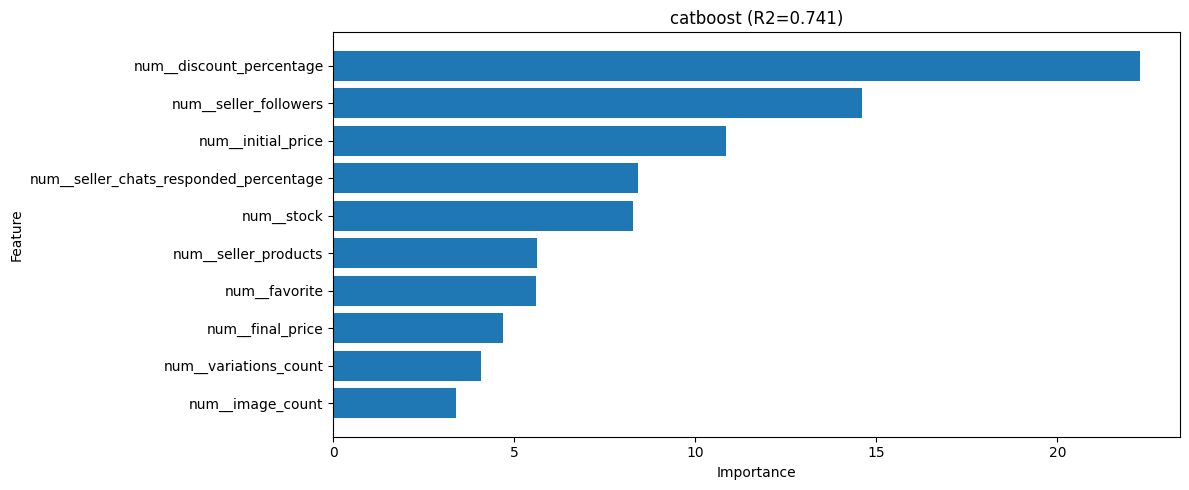

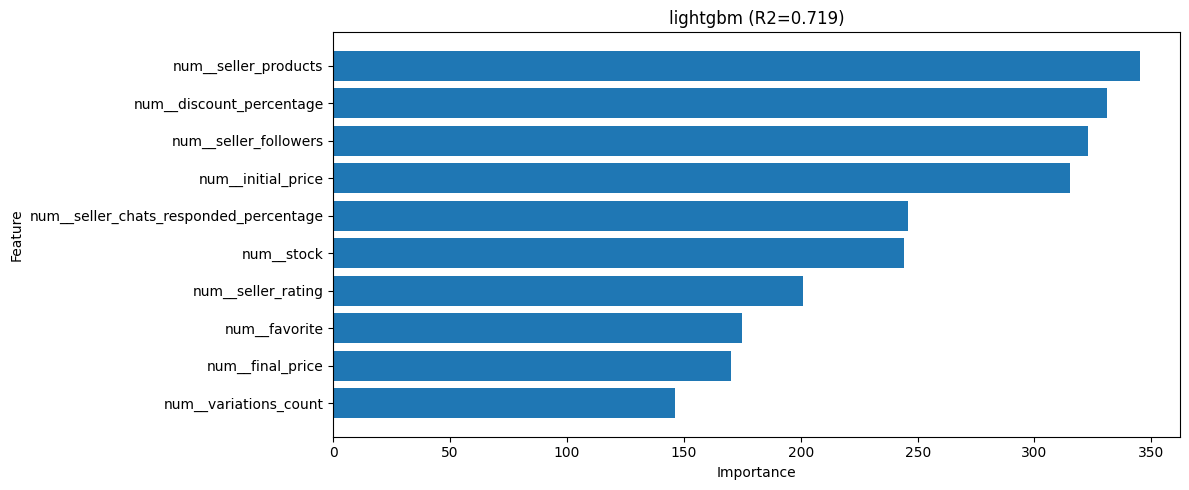

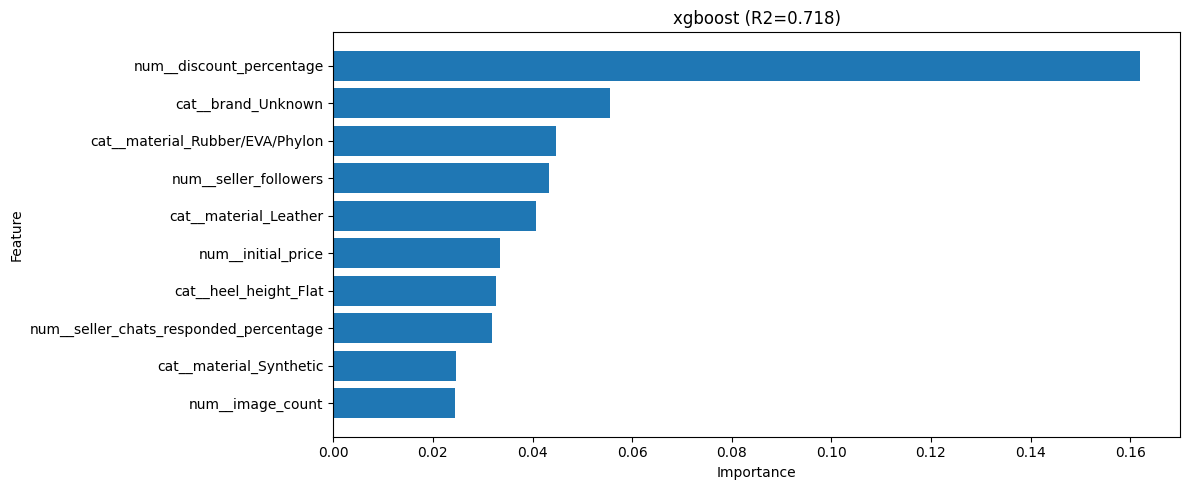

<Figure size 640x480 with 0 Axes>


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
              num__discount_percentage  116.588468
                  num__seller_products  115.447317
                 num__seller_followers  111.291389
                    num__initial_price  107.372373
num__seller_chats_responded_percentage   83.834524
                            num__stock   83.125080
                    num__seller_rating   67.289909
                         num__favorite   59.506617
                      num__final_price   57.543997
                 num__variations_count   49.441893


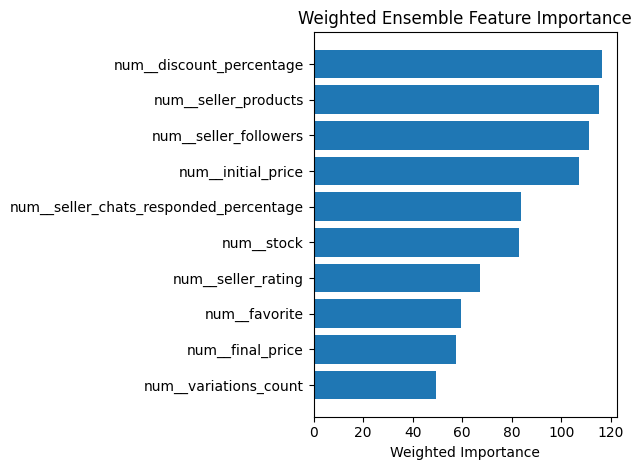


[STAGE] 11. MODEL PERFORMANCE TABLE
   model     rmse      mae       r2
ensemble 0.615180 0.433606 0.743969
catboost 0.619184 0.441733 0.740625
lightgbm 0.644355 0.450001 0.719109
 xgboost 0.645282 0.449997 0.718299
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 98%|===================| 978/1000 [00:35<00:00]        

[INFO] SHAP summary plot generating...


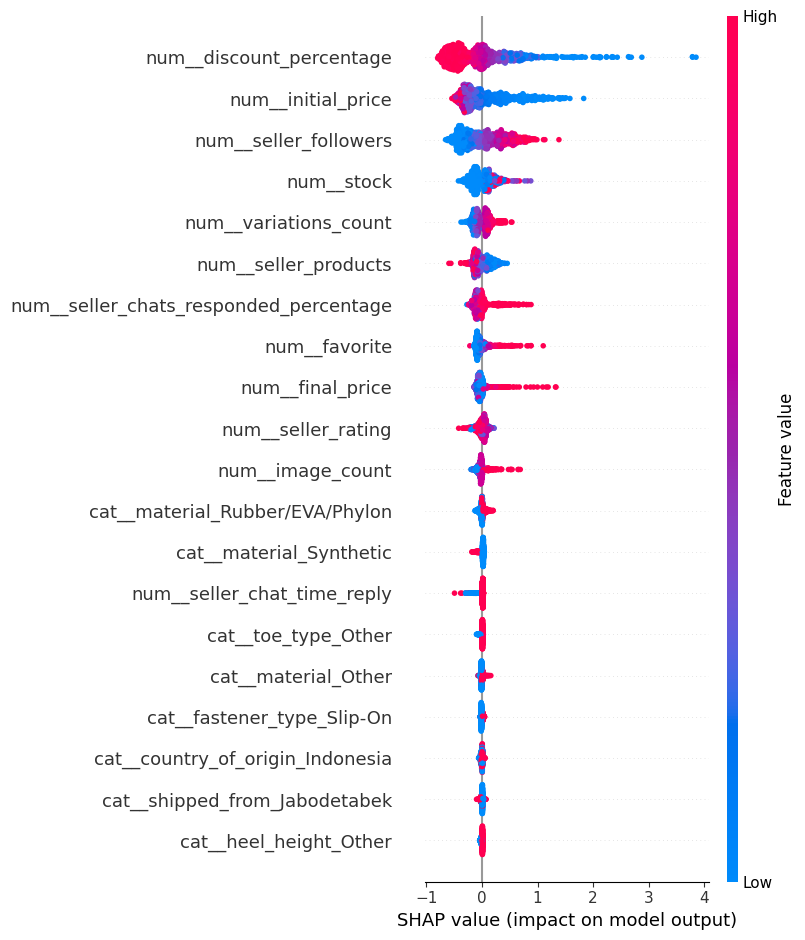


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature        positive_range         negative_range                             recommendation                                     interpretation                                insight
              num__discount_percentage      -590.02 – -18.51          83.33 – 98.68                 Reduce discount_percentage             discount_percentage ≈ -590.02 – -18.51  lower values drive better performance
                    num__initial_price    8000.00 – 43500.00 100000.00 – 1980000.00                       Reduce initial_price                 initial_price ≈ 8000.00 – 43500.00  lower values drive better performance
                 num__seller_followers 168004.70 – 406876.32        0.00 – 29568.38                  Increase seller_followers           seller_followers ≈ 168004.70 – 406876.32 higher values drive better performance
                            num__stock    105.00 – 383833.00           0.00 – 75.00                

C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

{'results_table':       model      rmse       mae        r2
 3  ensemble  0.615180  0.433606  0.743969
 0  catboost  0.619184  0.441733  0.740625
 1  lightgbm  0.644355  0.450001  0.719109
 2   xgboost  0.645282  0.449997  0.718299}

In [148]:
df_sandal = df_sandal.drop(columns=["seller_joined_date", "breadcrumb", "discount"], errors="ignore")
run_pipeline(df_sandal)

## WALLET MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2656, 48)
[INFO] Validation shape: (664, 48)
[INFO] Test shape: (831, 48)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.69900198 0.7141438 ]
[INFO] Weight STD: [0.0266245  0.02619162]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 49.46% ± 1.88%
[INFO] z_rating_credibility: 50.54% ± 1.85%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.699002    0.026625   49.464251 1.884059
z_rating_credibility    0.714144    0.026192   50.535749 1.853427

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 35

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 13
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_favorite', 'log_final_price', 'log_initial_price', 'log_stock', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_tim

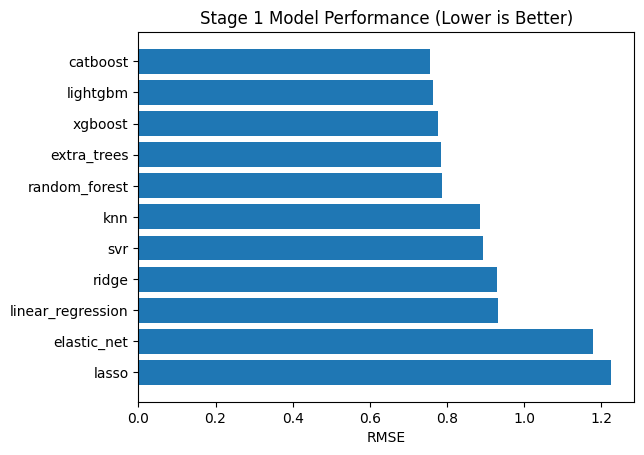

[I 2026-04-14 02:12:33,310] A new study created in memory with name: no-name-426ffd6a-868a-4a6f-b6d9-b3dfbd3b7310


[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-14 02:12:37,208] Trial 0 finished with value: 0.7670719165191472 and parameters: {'iterations': 553, 'depth': 5, 'learning_rate': 0.062267569212747016, 'l2_leaf_reg': 1.6256194835715518, 'border_count': 197}. Best is trial 0 with value: 0.7670719165191472.
[I 2026-04-14 02:13:17,525] Trial 1 finished with value: 0.7952311444325073 and parameters: {'iterations': 501, 'depth': 10, 'learning_rate': 0.013347270705776902, 'l2_leaf_reg': 6.340894827336598, 'border_count': 241}. Best is trial 0 with value: 0.7670719165191472.
[I 2026-04-14 02:13:22,982] Trial 2 finished with value: 0.758996621274098 and parameters: {'iterations': 278, 'depth': 7, 'learning_rate': 0.10014061526176352, 'l2_leaf_reg': 1.8699171187871384, 'border_count': 241}. Best is trial 2 with value: 0.758996621274098.
[I 2026-04-14 02:13:58,108] Trial 3 finished with value: 0.765570901929842 and parameters: {'iterations': 467, 'depth': 10, 'learning_rate': 0.030207892469566674, 'l2_leaf_reg': 8.1764073085699, 'bor

[INFO] Best params for catboost: {'iterations': 696, 'depth': 9, 'learning_rate': 0.08067733143946994, 'l2_leaf_reg': 9.466759632674128, 'border_count': 214}
0:	learn: 1.1962897	total: 7.31ms	remaining: 5.08s
1:	learn: 1.1673605	total: 9.38ms	remaining: 3.25s
2:	learn: 1.1378449	total: 15.8ms	remaining: 3.65s
3:	learn: 1.1161698	total: 23ms	remaining: 3.98s
4:	learn: 1.0923049	total: 29.3ms	remaining: 4.04s
5:	learn: 1.0695407	total: 36.1ms	remaining: 4.15s
6:	learn: 1.0487279	total: 42.7ms	remaining: 4.21s
7:	learn: 1.0290066	total: 49.3ms	remaining: 4.24s
8:	learn: 1.0109030	total: 56.7ms	remaining: 4.33s
9:	learn: 0.9951809	total: 63.2ms	remaining: 4.33s
10:	learn: 0.9803533	total: 71.4ms	remaining: 4.45s
11:	learn: 0.9640530	total: 78.3ms	remaining: 4.46s
12:	learn: 0.9493346	total: 85.9ms	remaining: 4.51s
13:	learn: 0.9372249	total: 92.6ms	remaining: 4.51s
14:	learn: 0.9248829	total: 99.7ms	remaining: 4.53s
15:	learn: 0.9145070	total: 107ms	remaining: 4.53s
16:	learn: 0.9044634	to

[I 2026-04-14 02:42:33,105] A new study created in memory with name: no-name-4b01ead8-6378-4f7b-8af7-f293374a1444


...

[I 2026-04-14 02:51:23,566] A new study created in memory with name: no-name-5c584a80-b6e6-4022-aa6b-beab9a263b47


[INFO] Tuning model: xgboost


[I 2026-04-14 02:51:26,029] Trial 0 finished with value: 0.7646680049497939 and parameters: {'n_estimators': 607, 'max_depth': 8, 'learning_rate': 0.01383520692396433, 'subsample': 0.8380221897440625, 'colsample_bytree': 0.6862704690020031, 'gamma': 1.0607661501159338, 'reg_lambda': 1.0113611483649319}. Best is trial 0 with value: 0.7646680049497939.
[I 2026-04-14 02:51:26,951] Trial 1 finished with value: 0.7947178505526674 and parameters: {'n_estimators': 416, 'max_depth': 5, 'learning_rate': 0.04373902509886799, 'subsample': 0.827523043776569, 'colsample_bytree': 0.6288550833019287, 'gamma': 3.830929963806727, 'reg_lambda': 7.45880842630464}. Best is trial 0 with value: 0.7646680049497939.
[I 2026-04-14 02:51:27,881] Trial 2 finished with value: 0.8177386243270272 and parameters: {'n_estimators': 318, 'max_depth': 3, 'learning_rate': 0.020937946856223872, 'subsample': 0.8630246731106964, 'colsample_bytree': 0.6822481057588468, 'gamma': 0.3962659300704391, 'reg_lambda': 3.87360544290

[INFO] Best params for xgboost: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.053491287614793714, 'subsample': 0.6680895124281067, 'colsample_bytree': 0.8065511544003299, 'gamma': 0.13677292325786336, 'reg_lambda': 5.300057725474678}

Tuning Summary:
  model  n_trials                                                                                                                                                                                                          best_params
xgboost       100 {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.053491287614793714, 'subsample': 0.6680895124281067, 'colsample_bytree': 0.8065511544003299, 'gamma': 0.13677292325786336, 'reg_lambda': 5.300057725474678}

[STAGE] 9. FINALIZE MODELS
[INFO] Training: catboost
[INFO] Training: lightgbm
[INFO] Training: xgboost

[STAGE] MODEL IMPROVEMENT (STAGE 1 vs STAGE 2)
   model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_improvement  r2_imp

<Figure size 1200x600 with 0 Axes>

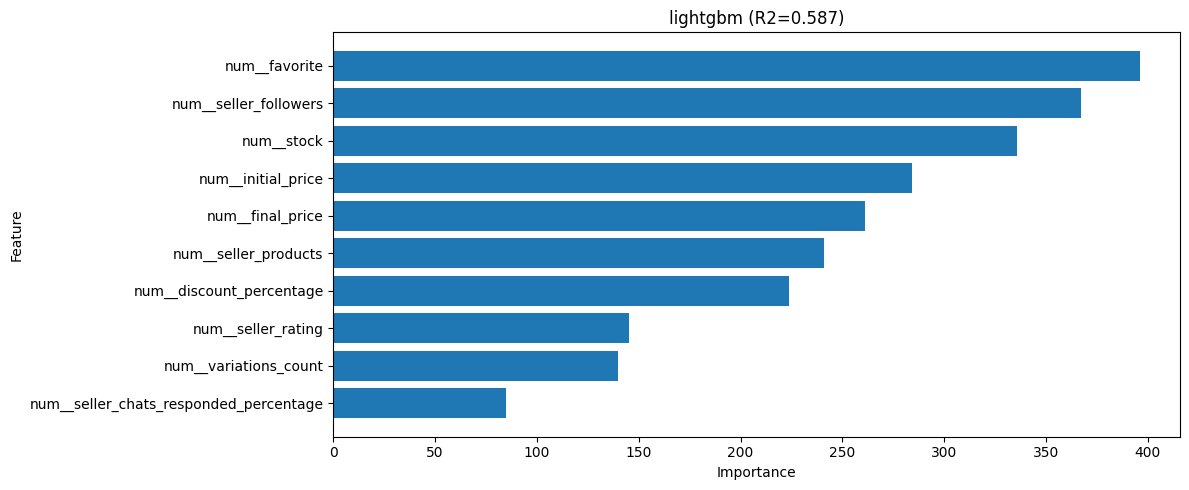

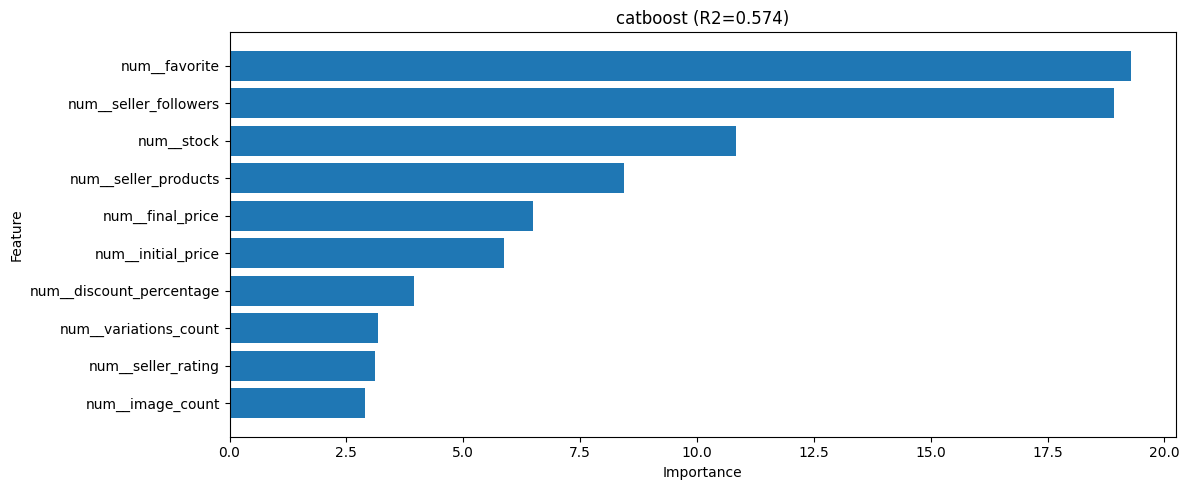

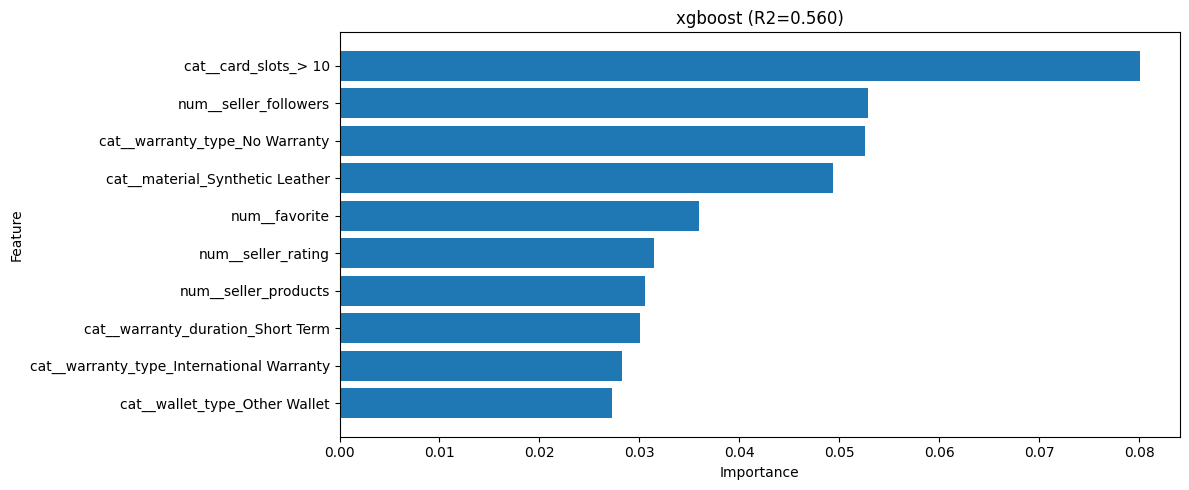

<Figure size 640x480 with 0 Axes>


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite  140.550499
                 num__seller_followers  130.611549
                            num__stock  117.413266
                    num__initial_price   98.149497
                      num__final_price   90.557674
                  num__seller_products   84.442418
              num__discount_percentage   77.181395
                    num__seller_rating   50.152397
                 num__variations_count   48.478090
num__seller_chats_responded_percentage   29.275938


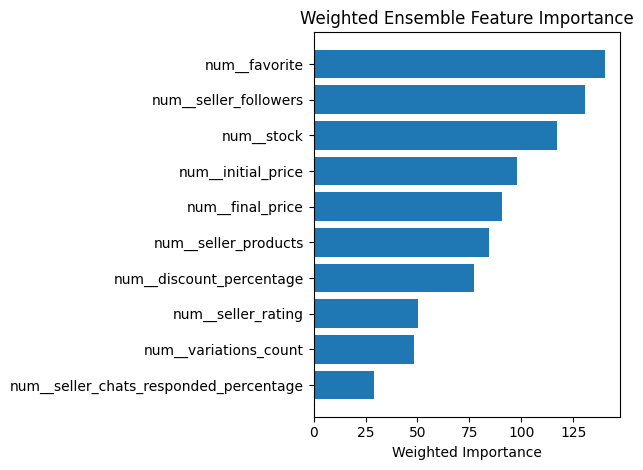


[STAGE] 11. MODEL PERFORMANCE TABLE
   model     rmse      mae       r2
ensemble 0.787791 0.452934 0.595376
lightgbm 0.795572 0.461168 0.587343
catboost 0.808357 0.475895 0.573974
 xgboost 0.821398 0.475005 0.560116
[INFO] Best model: lightgbm

[STAGE] 12. SHAP ANALYSIS
[INFO] SHAP summary plot generating...


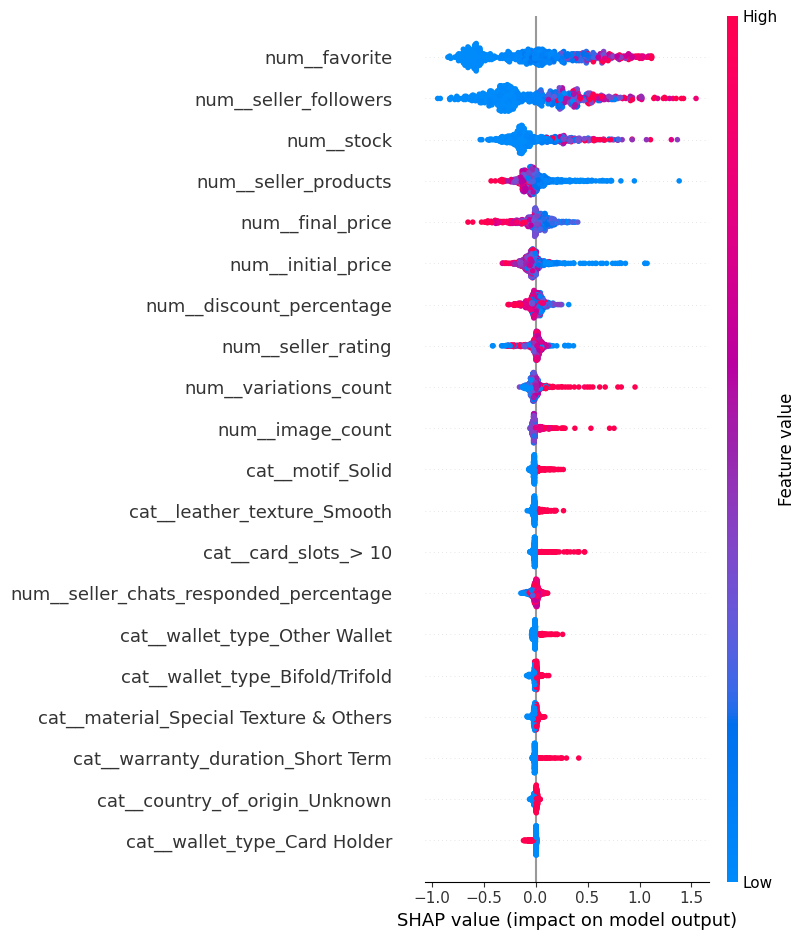


[STAGE] SHAP THRESHOLD ANALYSIS
                 feature       positive_range       negative_range             recommendation                          interpretation                                insight
           num__favorite       40.00 – 997.00         0.00 – 10.00          Increase favorite               favorite ≈ 40.00 – 997.00 higher values drive better performance
   num__seller_followers 50200.00 – 695400.00     20.00 – 26700.00  Increase seller_followers seller_followers ≈ 50200.00 – 695400.00 higher values drive better performance
              num__stock    217.00 – 24899.00        0.00 – 199.00             Increase stock               stock ≈ 217.00 – 24899.00 higher values drive better performance
    num__seller_products        6.00 – 802.00     124.00 – 1552.00     Reduce seller_products         seller_products ≈ 6.00 – 802.00  lower values drive better performance
        num__final_price   3999.00 – 89999.00 45000.00 – 439000.00         Reduce final_price        f

C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

{'results_table':       model      rmse       mae        r2
 3  ensemble  0.787791  0.452934  0.595376
 1  lightgbm  0.795572  0.461168  0.587343
 0  catboost  0.808357  0.475895  0.573974
 2   xgboost  0.821398  0.475005  0.560116}

In [149]:
df_wallet = df_wallet.drop(columns=["seller_joined_date", "breadcrumb", "discount", "log_gmv"], errors="ignore")
run_pipeline(df_wallet)

## PAN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2912, 42)
[INFO] Validation shape: (728, 42)
[INFO] Test shape: (911, 42)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.78165573 0.55633102]
[INFO] Weight STD: [0.1837334  0.21389752]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 58.42% ± 13.73%
[INFO] z_rating_credibility: 41.58% ± 15.99%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.781656    0.183733    58.42029 13.732079
z_rating_credibility    0.556331    0.213898    41.57971 15.986520

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 29

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 8
[INFO] # Binary: 2

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat

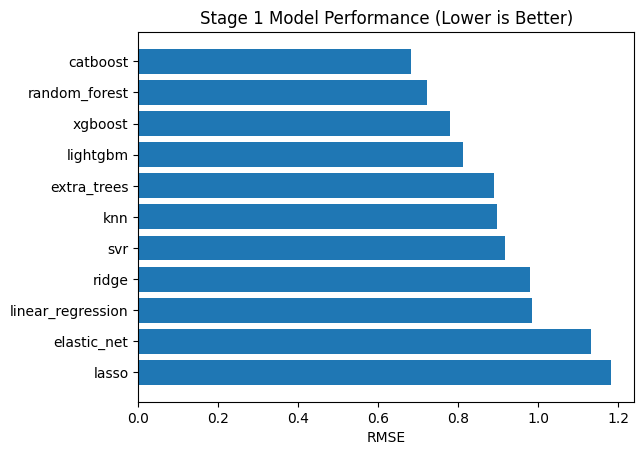

[I 2026-04-14 02:57:05,766] A new study created in memory with name: no-name-8c374ef7-c594-4944-a339-d3edd1c74dda


[INFO] Top models: ['catboost', 'random_forest', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-14 02:57:14,193] Trial 0 finished with value: 0.7268126823115791 and parameters: {'iterations': 430, 'depth': 8, 'learning_rate': 0.15342642019819624, 'l2_leaf_reg': 8.47097029414994, 'border_count': 122}. Best is trial 0 with value: 0.7268126823115791.
[I 2026-04-14 02:57:18,679] Trial 1 finished with value: 0.7090593889451432 and parameters: {'iterations': 282, 'depth': 7, 'learning_rate': 0.026200536119395372, 'l2_leaf_reg': 1.2598965067426866, 'border_count': 147}. Best is trial 1 with value: 0.7090593889451432.
[I 2026-04-14 02:57:25,464] Trial 2 finished with value: 0.7410991413289737 and parameters: {'iterations': 380, 'depth': 7, 'learning_rate': 0.03150331092187111, 'l2_leaf_reg': 5.431824496694387, 'border_count': 204}. Best is trial 1 with value: 0.7090593889451432.
[I 2026-04-14 02:57:43,354] Trial 3 finished with value: 0.774989265266144 and parameters: {'iterations': 494, 'depth': 10, 'learning_rate': 0.033712057465589106, 'l2_leaf_reg': 6.400863617282613, 'bor

[INFO] Best params for catboost: {'iterations': 799, 'depth': 6, 'learning_rate': 0.14680062408596642, 'l2_leaf_reg': 4.534674388075835, 'border_count': 248}
0:	learn: 1.1297889	total: 2.84ms	remaining: 2.27s
1:	learn: 1.0686719	total: 5.26ms	remaining: 2.1s
2:	learn: 1.0128021	total: 7.75ms	remaining: 2.06s
3:	learn: 0.9647969	total: 10.5ms	remaining: 2.08s
4:	learn: 0.9120681	total: 12.9ms	remaining: 2.05s
5:	learn: 0.8708690	total: 15.4ms	remaining: 2.03s
6:	learn: 0.8310356	total: 17.7ms	remaining: 2s
7:	learn: 0.7997341	total: 20.1ms	remaining: 1.98s
8:	learn: 0.7727498	total: 22.4ms	remaining: 1.96s
9:	learn: 0.7398258	total: 24.9ms	remaining: 1.96s
10:	learn: 0.7151608	total: 27.5ms	remaining: 1.97s
11:	learn: 0.6967708	total: 29.8ms	remaining: 1.96s
12:	learn: 0.6739255	total: 32.1ms	remaining: 1.94s
13:	learn: 0.6589114	total: 34.5ms	remaining: 1.94s
14:	learn: 0.6379054	total: 37ms	remaining: 1.93s
15:	learn: 0.6244318	total: 39.4ms	remaining: 1.93s
16:	learn: 0.6090700	total

[I 2026-04-14 03:06:03,000] A new study created in memory with name: no-name-eaac8396-6e74-460e-8082-4d0ca1fe5677


...

[I 2026-04-14 03:23:13,901] A new study created in memory with name: no-name-09301de0-ef22-4844-90b7-04362adbffac


[INFO] Tuning model: xgboost


[I 2026-04-14 03:23:14,697] Trial 0 finished with value: 0.7053909947261336 and parameters: {'n_estimators': 240, 'max_depth': 6, 'learning_rate': 0.030253364329949003, 'subsample': 0.7912620650674379, 'colsample_bytree': 0.7703250896837157, 'gamma': 1.1665986679359102, 'reg_lambda': 0.006837206723148536}. Best is trial 0 with value: 0.7053909947261336.
[I 2026-04-14 03:23:16,428] Trial 1 finished with value: 0.6925165234991463 and parameters: {'n_estimators': 327, 'max_depth': 7, 'learning_rate': 0.014767545727224463, 'subsample': 0.714837548390536, 'colsample_bytree': 0.7062222959328879, 'gamma': 0.40344289111373277, 'reg_lambda': 0.006766691913294439}. Best is trial 1 with value: 0.6925165234991463.
[I 2026-04-14 03:23:17,644] Trial 2 finished with value: 0.7389246512502904 and parameters: {'n_estimators': 379, 'max_depth': 9, 'learning_rate': 0.013774073281914179, 'subsample': 0.925555466959048, 'colsample_bytree': 0.7134112832473933, 'gamma': 4.26173007035338, 'reg_lambda': 0.3310

[INFO] Best params for xgboost: {'n_estimators': 730, 'max_depth': 4, 'learning_rate': 0.034226734409595935, 'subsample': 0.674449569258939, 'colsample_bytree': 0.8444921459139522, 'gamma': 0.24466889194247432, 'reg_lambda': 0.0023386463772828527}

Tuning Summary:
  model  n_trials                                                                                                                                                                                                             best_params
xgboost       100 {'n_estimators': 730, 'max_depth': 4, 'learning_rate': 0.034226734409595935, 'subsample': 0.674449569258939, 'colsample_bytree': 0.8444921459139522, 'gamma': 0.24466889194247432, 'reg_lambda': 0.0023386463772828527}

[STAGE] 9. FINALIZE MODELS
[INFO] Training: catboost
[INFO] Training: random_forest
[INFO] Training: xgboost

[STAGE] MODEL IMPROVEMENT (STAGE 1 vs STAGE 2)
        model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_

<Figure size 1200x600 with 0 Axes>

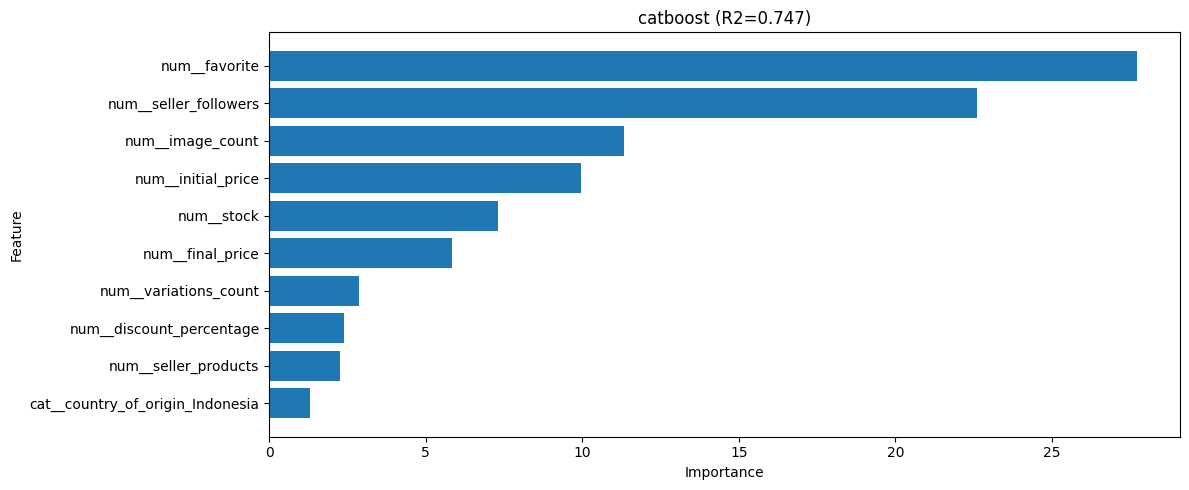

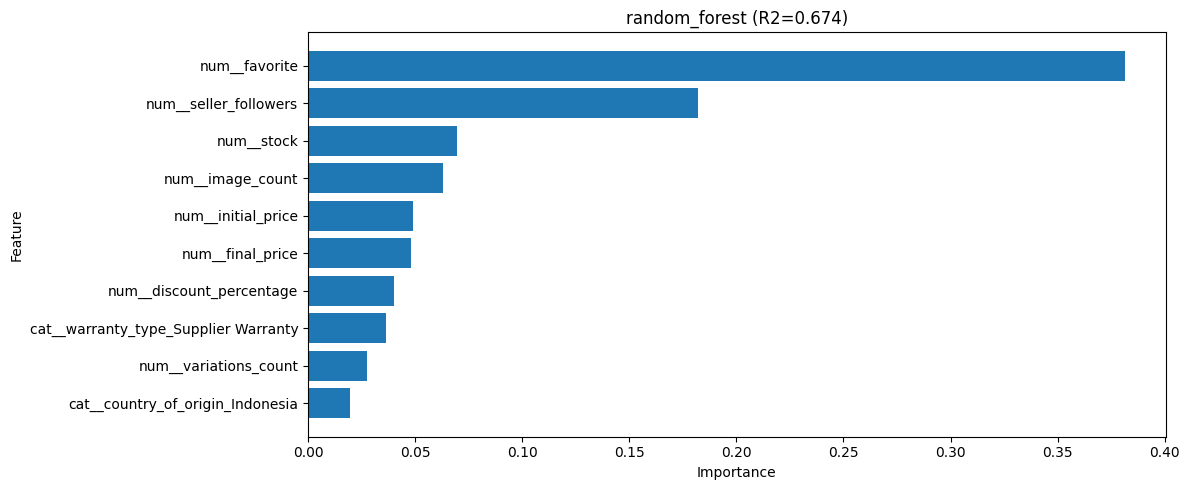

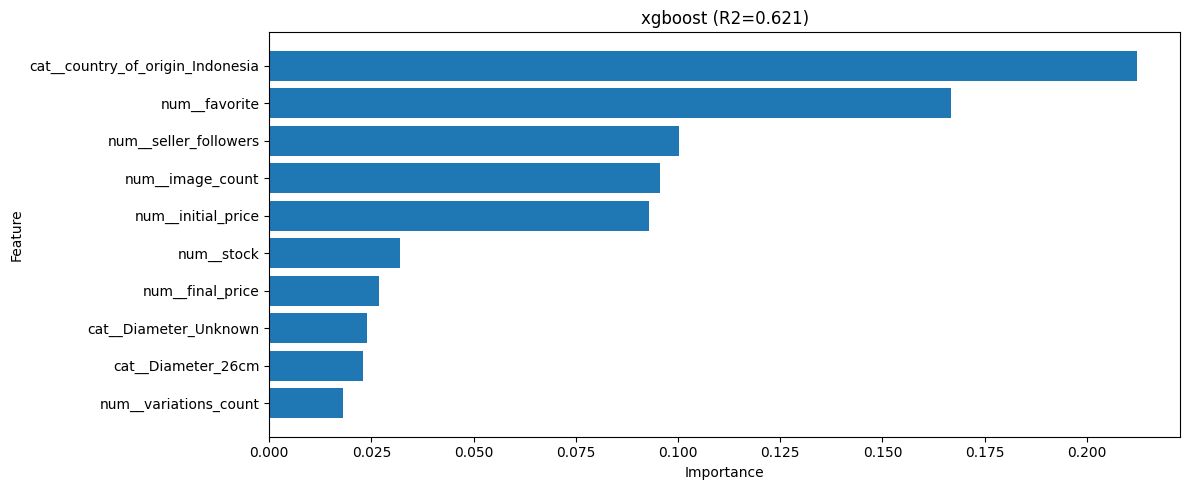

<Figure size 640x480 with 0 Axes>


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                         feature  importance
                   num__favorite   10.443717
           num__seller_followers    8.463208
                num__image_count    4.246332
              num__initial_price    3.738907
                      num__stock    2.741713
                num__final_price    2.187229
           num__variations_count    1.072986
        num__discount_percentage    0.903424
            num__seller_products    0.845055
cat__country_of_origin_Indonesia    0.551538


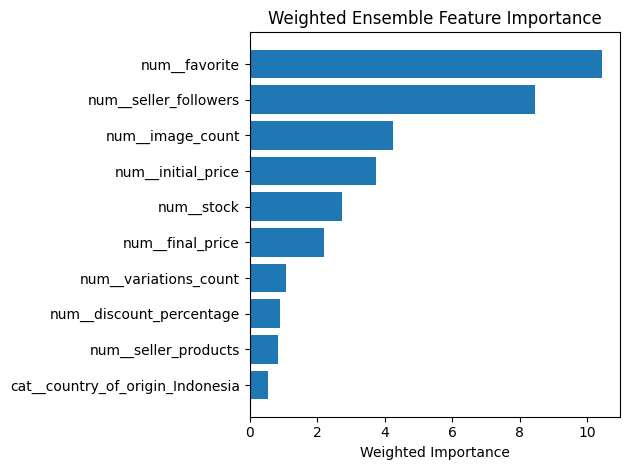


[STAGE] 11. MODEL PERFORMANCE TABLE
        model     rmse      mae       r2
     catboost 0.377407 0.185696 0.747032
     ensemble 0.392010 0.188730 0.727078
random_forest 0.428115 0.195395 0.674488
      xgboost 0.461990 0.212797 0.620939
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 99%|===================| 720/728 [00:19<00:00]        

[INFO] SHAP summary plot generating...


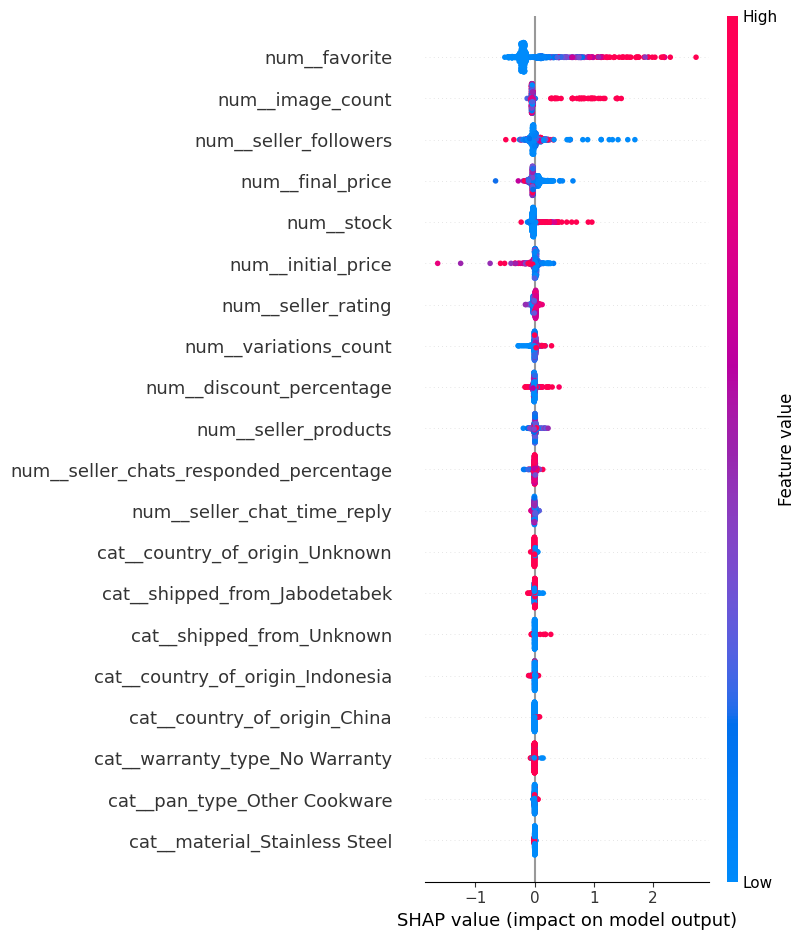


[STAGE] SHAP THRESHOLD ANALYSIS
                 feature      positive_range         negative_range             recommendation                       interpretation                                insight
           num__favorite     13.00 – 4938.00            0.00 – 6.00          Increase favorite           favorite ≈ 13.00 – 4938.00 higher values drive better performance
        num__image_count        2.00 – 17.00            1.00 – 9.00       Increase image_count           image_count ≈ 2.00 – 17.00 higher values drive better performance
   num__seller_followers   0.00 – 2413664.00     126.00 – 970000.00  Increase seller_followers seller_followers ≈ 0.00 – 2413664.00 higher values drive better performance
        num__final_price 8888.00 – 111000.00 121000.00 – 1429000.00         Reduce final_price    final_price ≈ 8888.00 – 111000.00  lower values drive better performance
              num__stock   0.00 – 1777657.00         0.00 – 4573.00             Increase stock            stock 

C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_16532\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

{'results_table':            model      rmse       mae        r2
 0       catboost  0.377407  0.185696  0.747032
 3       ensemble  0.392010  0.188730  0.727078
 1  random_forest  0.428115  0.195395  0.674488
 2        xgboost  0.461990  0.212797  0.620939}

In [150]:
df_pan = df_pan.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_pan)